# Multi-Objective Optimisation for determination of optimal number of crews based on the framework of the Battle of Postdisaster Response and Restoration (BPDRR)

This notebook is a test of the MOO of the optimal number of crews required to the framework used in the BPDRR

### Part 1: Imports, Inputs and Constants

This section imports all the Python libraries and input files required for the optimisation process, including Excel files, Parquet files and EPANET INP models.

It also defines the constants and parameters that remain fixed throughout a single optimisation run. These values describe the restoration scenario and provide the information required by all subsequent stages of the optimisation framework.

In [ ]:
#import sys
import os
import pandas as pd
import wntr
import matplotlib.pyplot as plt
import numpy as np

from time import perf_counter

In [6]:
#!{sys.executable} -m pip install pymoo
import pymoo
import time 

In [7]:
# Import the specific pymoo functions required for the BPDRR problem
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.ox import OrderCrossover
from pymoo.operators.mutation.inversion import InversionMutation
from pymoo.operators.sampling.rnd import PermutationRandomSampling
from pymoo.visualization.scatter import Scatter
from pymoo.termination import get_termination
from pymoo.optimize import minimize

In [8]:
# Import the specific functions required for the BPDRR problem
import OF_BPDRR as OF
import MOO_functions

In [9]:
# which damage scenario to analyse
ds_sel = 'DS2' 

In [10]:
# Import the water network model
inp_file = "BBM-EPS_"+ds_sel+"mcg.inp"
#inp_file = "BBM-EPS_"+ds_sel+"_restoration.inp"
wn = wntr.network.WaterNetworkModel(inp_file)

In [11]:
# Simulation settings
wn.options.time.duration = 7 * 24 * 3600       # 7 days
wn.options.time.hydraulic_timestep = 15 * 60     # 15 minutes
wn.options.time.report_timestep = 15 * 60        # 15 minutes

# Start simulation at 07:00 AM
wn.options.time.start_clocktime = 7 * 3600

# Pressure Driven Analysis
wn.options.hydraulic.demand_model = "PDA"
wn.options.hydraulic.required_pressure = 20
wn.options.hydraulic.minimum_pressure = 0
wn.options.hydraulic.pressure_exponent = 0.5

In [12]:
# timestep
dt = wn.options.time.hydraulic_timestep

# timestep in minutes
dtm = dt/60

In [13]:
# Number of crews available for the restoration
n_crews = 3

In [14]:
# # Optimisation parameters
# random_seed = 42

# # optimisation constants
# n_OFs = 6
# n_vars = None
# n_damaged_pipes = None

In [15]:
# Find all demand nodes (base demand > 0)
demand_nodes = []

# Expected demand at each node
#expected = {}

for node_name in wn.junction_name_list:

    node = wn.get_node(node_name)

    if node.base_demand > 0:

        demand_nodes.append(node_name)

print(f"Demand nodes found: {len(demand_nodes)}")

Demand nodes found: 4201


In [16]:
# Finding emitter nodes (nodes starting with "E_")
emitter_nodes = [
    j for j in wn.junction_name_list
    if j.startswith("E_")
]

# Demand at emitter nodes (leakage) over time
#leakage = demand[emitter_nodes]

In [17]:
# Expected demand
expected = wntr.metrics.expected_demand(wn)

expected *= 1000        # convert to L/s

expected = expected[demand_nodes]

expected.index = expected.index.astype(int)


In [18]:
# Read the repair times from the Excel file
df = pd.read_excel(
    "DS_with_full_description.xlsx",
    sheet_name= ds_sel
)

# Repair time discretization (hours)
repair_time_interval = 0.25  # 15 minutes

# Build the reparations dictionary
time_reparation = {}

for _, row in df.iterrows():

    repair_time = float(row["fix time (hours)"])

    # Round up to the nearest interval
    repair_time = np.ceil(repair_time / repair_time_interval) * repair_time_interval

    time_reparation[str(row["Pipe ID"])] = {
        "t_r": repair_time
    }

print(f"{len(time_reparation)} repairs loaded.")
# time_reparation

106 repairs loaded.


In [19]:
# Pipe IDs from the reparations dictionary
pipe_ids = list(time_reparation.keys())

# Number of repairs
n_rep = len(pipe_ids)

In [20]:
# Import the travel time matrix from the parquet file
dmatrix_df = pd.read_parquet(
    "TravelTime_"+ds_sel+".parquet"
)

# Normalize IDs so the repair dictionary and matrix use the same keys
dmatrix_df.index = dmatrix_df.index.map(str)
dmatrix_df.columns = dmatrix_df.columns.map(str)

dmatrix_df.head()

,1951,3414,4988,5251,3404,6005,1252,2408,3094,3293,...,538,5488,5567,5677,5778,5959,6041,854,869,892
1951,0.25,0.25,0.25,0.75,0.25,0.75,0.50,0.25,0.25,0.25,...,0.25,0.75,0.75,0.75,0.75,0.75,0.75,0.50,0.50,0.50
3414,0.25,0.25,0.25,0.50,0.25,0.75,0.25,0.25,0.25,0.25,...,0.25,0.50,0.75,0.50,0.75,0.75,0.75,0.25,0.25,0.25
4988,0.25,0.25,0.25,0.50,0.25,0.75,0.25,0.25,0.25,0.25,...,0.25,0.75,0.75,0.50,0.75,0.75,0.75,0.25,0.25,0.25
5251,0.75,0.50,0.50,0.25,0.75,0.25,0.50,0.50,0.75,0.50,...,0.50,0.25,0.25,0.25,0.25,0.25,0.25,0.50,0.50,0.50
3404,0.25,0.25,0.25,0.75,0.25,0.75,0.25,0.25,0.25,0.25,...,0.25,0.75,0.75,0.75,0.75,0.75,0.75,0.25,0.25,0.25


In [21]:
# List of indexes corresponding to the pipe IDs to be repaired
indexes = list(range(len(pipe_ids)))
#indexes

In [22]:
# The name of the temporal restoration input file that will be used during the optimisation process
temp_inp="temp_restoration.inp"

In [23]:
# The scenario dictionary contains all the information required to run the optimisation process

scenario = {

    # Restoration
    "damaged_inp": inp_file,
    "reparations": time_reparation,
    "dmatrix": dmatrix_df,
    "pipe_ids": pipe_ids,
    "n_crews": n_crews,
    "temp_inp": temp_inp,
    # ---------------------------------------------------------
    # Hydraulic data
    # ---------------------------------------------------------

    "demand_nodes": demand_nodes,
    "emitter_nodes": emitter_nodes,
    "expected": expected,

    # ---------------------------------------------------------
    # Time
    # ---------------------------------------------------------

    "dt": dt,
    "dtm": dtm,

    # ---------------------------------------------------------
    # Simulation settings
    # ---------------------------------------------------------

    "duration": wn.options.time.duration,
    "hydraulic_timestep": wn.options.time.hydraulic_timestep,
    "report_timestep": wn.options.time.report_timestep,

    "demand_model": wn.options.hydraulic.demand_model,
    "required_pressure": wn.options.hydraulic.required_pressure,
    "minimum_pressure": wn.options.hydraulic.minimum_pressure,
    "pressure_exponent": wn.options.hydraulic.pressure_exponent,

    # ---------------------------------------------------------
    # Objective constants
    # ---------------------------------------------------------

    "service_ratio": 0.5,
    "consecutive_hours": 8,

}

### Part 2: Restoration Simulation

This section defines the functions responsible for generating a repair schedule from a candidate solution, creating the corresponding EPANET controls, and performing the hydraulic simulation of the restoration process.

The output of this section is a hydraulic simulation that can be evaluated using the objective functions.

In [24]:
# Function to simulate the restoration process
def simulate_restoration(
    indexes,
    scenario,
    save_temp_inp=False,
):
    """
    Run one hydraulic restoration simulation.

    Parameters
    ----------
    indexes : list
        Permutation of damaged pipes (decision variable).

    scenario : dict
        Dictionary containing all fixed information for the
        restoration scenario.

    temp_inp : str
        Temporary INP file used during the simulation.

    save_temp_inp : bool, optional
        If True, the temporary INP is kept after the simulation.
        Otherwise it is deleted.

    Returns
    -------
    simulation : dict

        {
            "results" : SimulationResults,
            "schedule": pandas.DataFrame,
            "network" : WaterNetworkModel
        }
    """

    # Create repair schedule

    schedule = MOO_functions.create_schedule(

        reparations=scenario["reparations"],

        dmatrix=scenario["dmatrix"],

        pipe_ids=scenario["pipe_ids"],

        indexes=indexes,

        n_crews=scenario["n_crews"],

    )

    # Generate EPANET controls

    controls = MOO_functions.generate_controls(
        schedule
    )

    # Create temporary INP

    MOO_functions.write_inp_controls(

        input_inp=scenario["damaged_inp"],

        output_inp=scenario["temp_inp"],

        schedule=schedule,

        new_controls=controls,

    )

    # Load temporary network

    wn = wntr.network.WaterNetworkModel(scenario["temp_inp"])

    wn.options.time.duration = scenario["duration"]
    wn.options.time.hydraulic_timestep = scenario["hydraulic_timestep"]
    wn.options.time.report_timestep = scenario["report_timestep"]
    wn.options.hydraulic.demand_model = scenario["demand_model"]
    wn.options.hydraulic.required_pressure = scenario["required_pressure"]
    wn.options.hydraulic.minimum_pressure = scenario["minimum_pressure"]
    wn.options.hydraulic.pressure_exponent = scenario["pressure_exponent"]
   
    # Run hydraulic simulation
    
    sim = wntr.sim.EpanetSimulator(wn)

    results = sim.run_sim()

    # Remove temporary INP

    if not save_temp_inp:

        try:
            os.remove(scenario["temp_inp"])

        except FileNotFoundError:
            pass

    # Return simulation

    simulation = {

        "results": results,

        "schedule": schedule,

        "network": wn,

    }

    return simulation

In [25]:
# # ============================================================
# # INTEGRATION TEST - OBJECTIVE FUNCTIONS
# # ============================================================

# # Run one restoration simulation
# simulation = simulate_restoration(
#     indexes=indexes,
#     scenario=scenario,
# #    temp_inp=temp_inp,
#     save_temp_inp=False
# )

# # ------------------------------------------------------------
# # Extract simulation results
# # ------------------------------------------------------------

# results = simulation["results"]

# demand = results.node["demand"] * 1000  # convert to L/s

# pressure = results.node["pressure"]

# flowrate = results.link["flowrate"]


# # ------------------------------------------------------------
# # Supply ratio
# # ------------------------------------------------------------

# supply_ratio = (
#     demand[scenario["demand_nodes"]]
#     / scenario["expected"]
# )

# # ------------------------------------------------------------
# # Objective 1 - FH
# # ------------------------------------------------------------

# FH, FH_undersupplied = OF.OF_FH(
#     supply_ratio=supply_ratio,
#     dtm=scenario["dtm"]
# )

# # ------------------------------------------------------------
# # Objective 2 - t95
# # ------------------------------------------------------------

# t95 = OF.OF_t95(
#     demand=demand,
#     demand_nodes=scenario["demand_nodes"],
#     expected=scenario["expected"],
#     dtm=scenario["dtm"]
# )

# # ------------------------------------------------------------
# # Objective 3 - RL
# # ------------------------------------------------------------

# RL = OF.OF_RL(
#     demand=demand,
#     demand_nodes=scenario["demand_nodes"],
#     expected=scenario["expected"],
#     dtm=scenario["dtm"]
# )

# # ------------------------------------------------------------
# # Objective 4 - Time without service
# # ------------------------------------------------------------

# TNS = OF.OF_time_no_serv(
#     supply_ratio=supply_ratio,
#     dtm=scenario["dtm"],
#     ratio=scenario["service_ratio"]
# )

# # ------------------------------------------------------------
# # Objective 5 - NWSECH
# # ------------------------------------------------------------

# NWSECH = OF.OF_NWSECH(
#     supply_ratio=supply_ratio,
#     dtm=scenario["dtm"],
#     ratio=scenario["service_ratio"],
#     hours=scenario["consecutive_hours"]
# )

# # ------------------------------------------------------------
# # Objective 6 - Water loss
# # ------------------------------------------------------------

# WL = OF.OF_WL(
#     demand=demand,
#     emitter_nodes=scenario["emitter_nodes"],
#     dt=scenario["dt"]
# )

# # ------------------------------------------------------------
# # Print results
# # ------------------------------------------------------------

# print(f"FH      = {FH:.2f}")
# print(f"t95     = {t95:.2f}")
# print(f"RL      = {RL:.2f}")
# print(f"TNS     = {TNS:.2f}")
# print(f"NWSECH  = {NWSECH}")
# print(f"WL      = {WL:.2f}")

In [26]:
#functionality_series = OF.system_functionality(demand, demand_nodes, expected)

In [27]:
# # Plot functionality over the simulation period
# time_hours = functionality_series.index.to_numpy() / 3600

# fig, ax = plt.subplots(figsize=(10, 5))
# ax.plot(time_hours, functionality_series.to_numpy(), color="tab:blue", linewidth=2,
#         label="System functionality")
# ax.axhline(100, color="black", linestyle="--", linewidth=1, label="Full functionality")
# ax.axhline(95, color="tab:green", linestyle=":", linewidth=1.5, label="95% threshold")

# # Shade the resilience loss: the area between actual and full functionality.
# ax.fill_between(time_hours, functionality_series.to_numpy(), 100,
#                 color="tab:red", alpha=0.15, label="Resilience loss")

# # t95 is stored in seconds; show it only if 95% functionality is reached permanently.
# if np.isfinite(t95):
#     t95_hours = t95 / 60
#     ax.axvline(t95_hours, color="tab:green", linestyle="--", linewidth=1.5)
#     ax.annotate(f"t95 = {t95_hours:.1f} h", xy=(t95_hours, 95),
#                 xytext=(6, 8), textcoords="offset points", color="tab:green")

# ax.set(title=f"System functionality – {ds_sel}", xlabel="Time after earthquake [hours]",
#        ylabel="Functionality [%]", ylim=(75, 105))
# ax.grid(True, alpha=0.3)
# ax.legend(loc="best")
# fig.tight_layout()
# plt.show()

# # Optional: save a publication-quality copy.
# # fig.savefig(f"functionality_{ds_sel}.png", dpi=300, bbox_inches="tight")

### Part 3: Objective Function Evaluation

This section evaluates the hydraulic simulation produced in Part 2 using the six objective functions being used.

The resulting objective vector represents the performance of a candidate repair schedule and will be used by the optimisation algorithm.

In [28]:
def evaluate_solution(
    indexes,
    scenario,
#    temp_inp,
):
    """
    Evaluate one restoration solution.

    Parameters
    ----------
    indexes : list or ndarray
        Permutation of damaged pipes.

    scenario : dict
        Dictionary containing all fixed information for the
        restoration scenario.

    temp_inp : str
        Temporary INP file used during the hydraulic simulation.

    Returns
    -------
    numpy.ndarray

        Objective vector:

        [
            FH,
            t95,
            RL,
            TNS,
            NWSECH,
            WL
        ]
    """

    # ---------------------------------------------------------
    # Run restoration simulation
    # ---------------------------------------------------------

    simulation = simulate_restoration(
        indexes,
        scenario,
        save_temp_inp=True,
    )

    # ---------------------------------------------------------
    # Extract hydraulic results
    # ---------------------------------------------------------

    results = simulation["results"]

    demand = results.node["demand"] * 1000  # convert to L/s

    # Supply ratio
    supply_ratio = (
        demand[scenario["demand_nodes"]]
        / scenario["expected"]
    )

    # ---------------------------------------------------------
    # Objective 1 - FH
    # ---------------------------------------------------------

    FH, _ = OF.OF_FH(
        supply_ratio=supply_ratio,
        dtm=scenario["dtm"],
    )

    # ---------------------------------------------------------
    # Objective 2 - t95
    # ---------------------------------------------------------

    t95 = OF.OF_t95(
        demand=demand,
        demand_nodes=scenario["demand_nodes"],
        expected=scenario["expected"],
        dtm=scenario["dtm"],
    )

    # ---------------------------------------------------------
    # Objective 3 - Resilience Loss
    # ---------------------------------------------------------

    RL = OF.OF_RL(
        demand=demand,
        demand_nodes=scenario["demand_nodes"],
        expected=scenario["expected"],
        dtm=scenario["dtm"],
    )

    # ---------------------------------------------------------
    # Objective 4 - Time without service
    # ---------------------------------------------------------

    TNS = OF.OF_time_no_serv(
        supply_ratio=supply_ratio,
        dtm=scenario["dtm"],
        ratio=scenario["service_ratio"],
    )

    # ---------------------------------------------------------
    # Objective 5 - Nodes without service > 8 h
    # ---------------------------------------------------------

    NWSECH = OF.OF_NWSECH(
        supply_ratio=supply_ratio,
        dtm=scenario["dtm"],
        ratio=scenario["service_ratio"],
        hours=scenario["consecutive_hours"],
    )

    # ---------------------------------------------------------
    # Objective 6 - Water loss
    # ---------------------------------------------------------

    WL = OF.OF_WL(
        demand=demand,
        emitter_nodes=scenario["emitter_nodes"],
        dt=scenario["dt"],
    )

    # ---------------------------------------------------------
    # Objective vector
    # ---------------------------------------------------------

    objectives = np.array([
        FH,
        t95,
        RL,
        TNS,
        NWSECH,
        WL,
    ])

    return objectives

In [29]:
solution = evaluate_solution(indexes, scenario)
print(f"{solution[0]:.2f}, {solution[1]:.2f}, {solution[2]:.2f}, {solution[3]:.2f}, {solution[4]}, {solution[5]:.2f}")

795.00, 4020.00, 15850.96, 65.16, 3.0, 63407.45


### Part 4: Multi-Objective Optimisation

This section defines the optimisation problem and configures the NSGA-II algorithm. Candidate repair schedules are generated, evaluated and evolved to approximate the Pareto-optimal set of permutations of the pipe repair orders.

In [30]:
class BPDRRProblem(ElementwiseProblem):
    """
    Multi-objective restoration scheduling problem.

    Decision variable:
        Permutation of the damaged pipes.

    Objectives:
        1. FH
        2. t95
        3. RL
        4. Time without service
        5. NWSECH
        6. Water loss
    """

    def __init__(self, scenario):

        self.scenario = scenario
        self.n_eval = 0

        n_pipes = len(scenario["pipe_ids"])

        super().__init__(
            n_var=n_pipes,
            n_obj=6,
            n_ieq_constr=0,
            xl=0,
            xu=n_pipes - 1,
            vtype=int,
        )

    def _evaluate(self, x, out, *args, **kwargs):

        self.n_eval += 1

        # Convert to integer permutation
        indexes = np.asarray(x, dtype=int)

        # Evaluate restoration schedule
        objectives = evaluate_solution(
            indexes=indexes,
            scenario=self.scenario,
        )

        out["F"] = np.asarray(objectives, dtype=float)

In [31]:
problem = BPDRRProblem(scenario)

x = np.array(indexes)

out = {}

problem._evaluate(x, out)

print(out["F"])

[7.950e+02 4.020e+03 1.585e+04 6.516e+01 3.000e+00 6.341e+04]


In [32]:
# NSGA-II PARAMETERS

pop_size = 20

n_generations = 20

seed = 1

In [33]:
algorithm = NSGA2(
    pop_size,
    sampling= PermutationRandomSampling(),
    crossover= OrderCrossover(),
    mutation= InversionMutation(),
    eliminate_duplicates=True
)

### Part 5: Results and Pareto Analysis

This section executes the optimisation process and analyses the resulting Pareto-optimal solutions. The objective values and repair schedules are compared to identify the trade-offs between different restoration strategies.

In [34]:
result = minimize(
    problem=problem,
    algorithm=algorithm,
    termination=("n_gen", n_generations),
    seed=seed,
    save_history=True,
    verbose=True,
)

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       20 |     11 |             - |             -
     2 |       40 |     18 |  0.8571428571 |         nadir
     3 |       60 |     20 |  0.0911165682 |         ideal
     4 |       80 |     20 |  0.2044678402 |         ideal
     5 |      100 |     20 |  0.2102443306 |         ideal
     6 |      120 |     20 |  0.2941176471 |         nadir
     7 |      140 |     20 |  0.0908545822 |         ideal
     8 |      160 |     18 |  0.1731272681 |         ideal
     9 |      180 |     20 |  0.0114285714 |         nadir
    10 |      200 |     17 |  0.1105314969 |         ideal
    11 |      220 |     20 |  0.4680851064 |         ideal
    12 |      240 |     17 |  0.1677811608 |         nadir
    13 |      260 |     10 |  0.0243902439 |         ideal
    14 |      280 |     15 |  0.0714285714 |         ideal
    15 |      300 |     18 |  0.0611828282 |         ideal
    16 |      320 |     20 |  0.0332821260 |         ide

In [35]:
print(result.X.shape)
print(result.F.shape)

(20, 106)
(20, 6)


In [ ]:
print(result.F)

In [ ]:
#print(result.X)
pareto_solutions = pd.DataFrame(
    result.X,
    index=[f"Solution {i}" for i in range(len(result.X))]
)

pareto_solutions

# Export the Pareto solutions to a CSV file
pareto_solutions.to_csv("pareto_solutions.csv", index=True)

,0,1,2,3,4,5,6,7,8,9,...,96,97,98,99,100,101,102,103,104,105
Solution 0,3,81,54,67,7,29,14,102,0,63,...,57,65,58,35,17,28,88,72,96,16
Solution 1,3,7,0,25,71,62,6,5,8,40,...,34,36,31,76,93,101,82,43,11,24
Solution 2,24,0,70,5,8,73,6,101,43,23,...,27,71,82,12,30,19,49,102,51,14
Solution 3,6,5,101,3,7,43,73,23,24,44,...,79,93,76,12,49,60,83,72,19,14
Solution 4,0,7,31,35,67,99,63,25,81,3,...,76,66,32,64,34,27,71,19,102,14
Solution 5,6,5,101,3,7,43,73,23,24,44,...,36,34,64,12,49,60,83,72,19,14
Solution 6,3,81,67,7,14,0,25,71,62,6,...,34,64,96,12,49,60,83,43,11,24
Solution 7,24,70,5,8,73,6,101,43,23,7,...,27,71,82,12,30,19,49,102,51,14
Solution 8,24,14,87,10,2,78,75,4,39,104,...,45,54,65,57,102,48,68,19,49,51
Solution 9,6,5,101,11,3,7,43,73,23,24,...,38,33,68,92,17,28,85,88,46,96


In [38]:
objective_names = [
    "FH",
    "t95",
    "RL",
    "TNS",
    "NWSECH",
    "WL"
]

pareto_df = pd.DataFrame(
    result.F,
    columns=objective_names
)

pareto_df

,FH,t95,RL,TNS,NWSECH,WL
0,0.0,5460.0,13256.139153,12.961200,1.0,73176.359375
1,90.0,5460.0,13251.978871,16.121162,1.0,72102.171875
2,885.0,4020.0,14608.447310,50.677220,4.0,67944.820312
3,1140.0,5430.0,16122.600666,53.726494,3.0,68293.453125
4,0.0,6900.0,13745.228741,18.131397,3.0,73085.726562
5,630.0,5460.0,16439.555230,39.169245,4.0,68964.820312
6,390.0,5460.0,13769.677764,27.336348,0.0,71776.523438
7,765.0,4020.0,15070.555188,46.892407,15.0,69429.968750
8,180.0,6705.0,15793.136826,29.614378,5.0,69275.523438
9,735.0,4020.0,15942.227609,44.496548,14.0,68372.234375


In [39]:
pareto_df.describe()

,FH,t95,RL,TNS,NWSECH,WL
count,20.000000,20.000000,20.000000,20.000000,20.00000,20.000000
mean,407.250000,5416.500000,14762.554946,30.790705,3.40000,70292.115234
std,367.561219,974.093506,1008.215379,13.336837,4.00526,1713.593524
min,0.000000,4020.000000,13251.978871,12.961200,0.00000,67944.820312
25%,67.500000,5092.500000,14057.889198,18.425970,1.00000,68901.238281
50%,345.000000,5460.000000,14600.682334,28.835991,2.00000,69883.097656
75%,742.500000,5786.250000,15625.586534,43.894013,3.25000,71797.287109
max,1140.000000,6900.000000,16439.555230,53.726494,15.00000,73176.359375


In [40]:
def plot_pareto(result, x_obj, y_obj):
    """
    Plot a Pareto front between two objectives.
    """

    x = pareto_df[x_obj]
    y = pareto_df[y_obj]

    plt.figure(figsize=(6, 5))

    plt.scatter(x, y)

    plt.xlabel(x_obj)
    plt.ylabel(y_obj)

    plt.title(f"{y_obj} vs {x_obj}")

    plt.grid(True)

    plt.tight_layout()

    plt.show()

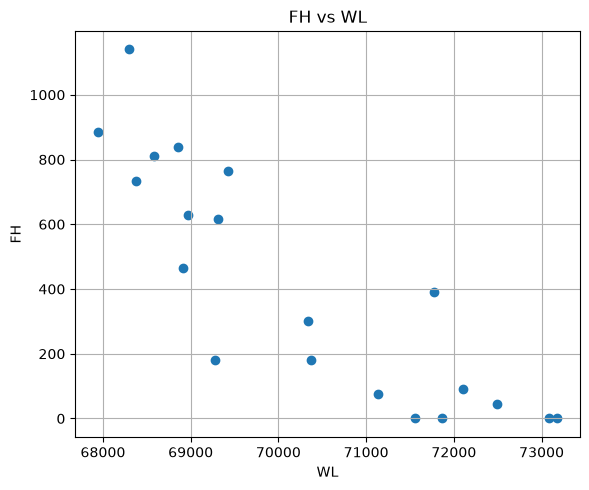

In [41]:
plot_pareto(result, "WL", "FH")

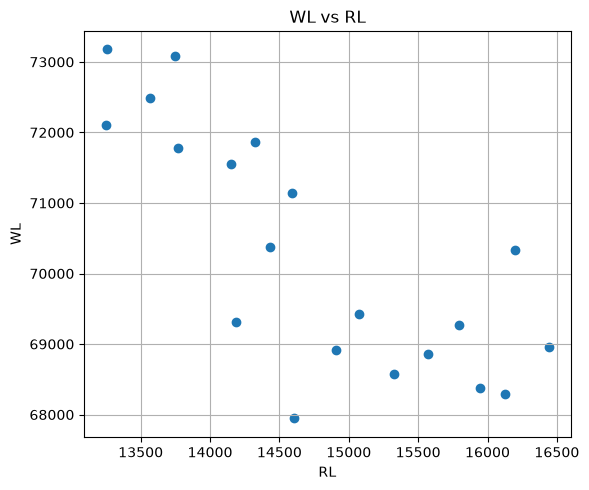

In [42]:
plot_pareto(result, "RL", "WL")

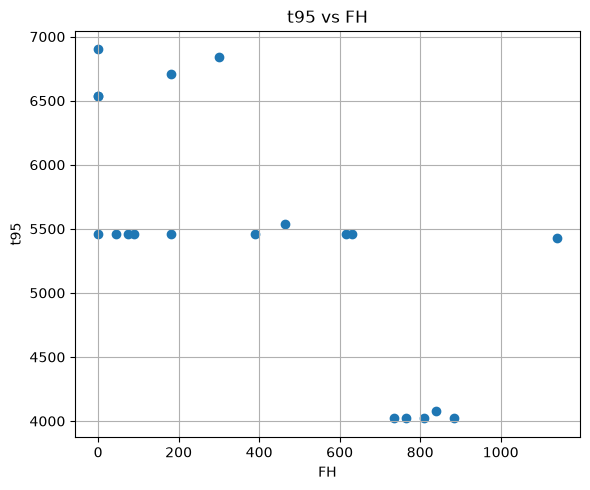

In [43]:
plot_pareto(result, "FH", "t95")

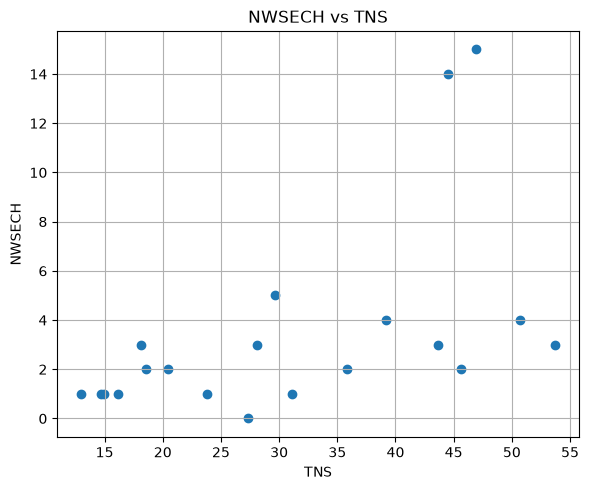

In [44]:
plot_pareto(result, "TNS", "NWSECH")